In [1]:
import os 
df= os.listdir("stack-overflow-developer-survey-2020")
df

['.ipynb_checkpoints',
 'README_2020.txt',
 'so_survey_2020.pdf',
 'survey_results_public.csv',
 'survey_results_schema.csv']

In [2]:
import pandas as pd
survey_raw_df=pd.read_csv("stack-overflow-developer-survey-2020/survey_results_public.csv")
survey_raw_df

,Respondent,MainBranch,Hobbyist,Age,Age1stCode,CompFreq,CompTotal,ConvertedComp,Country,CurrencyDesc,...,SurveyEase,SurveyLength,Trans,UndergradMajor,WebframeDesireNextYear,WebframeWorkedWith,WelcomeChange,WorkWeekHrs,YearsCode,YearsCodePro
0,1,I am a developer by profession,Yes,NaN,13,Monthly,NaN,NaN,Germany,European Euro,...,Neither easy nor difficult,Appropriate in length,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET;ASP.NET Core,Just as welcome now as I felt last year,50.0,36,27
1,2,I am a developer by profession,No,NaN,19,NaN,NaN,NaN,United Kingdom,Pound sterling,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat more welcome now than last year,NaN,7,4
2,3,I code primarily as a hobby,Yes,NaN,15,NaN,NaN,NaN,Russian Federation,NaN,...,Neither easy nor difficult,Appropriate in length,NaN,NaN,NaN,NaN,Somewhat more welcome now than last year,NaN,4,NaN
3,4,I am a developer by profession,Yes,25.0,18,NaN,NaN,NaN,Albania,Albanian lek,...,NaN,NaN,No,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat less welcome now than last year,40.0,7,4
4,5,"I used to be a developer by profession, but no...",Yes,31.0,16,NaN,NaN,NaN,United States,NaN,...,Easy,Too short,No,"Computer science, computer engineering, or sof...",Django;Ruby on Rails,Ruby on Rails,Just as welcome now as I felt last year,NaN,15,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,64858,NaN,Yes,NaN,16,NaN,NaN,NaN,United States,NaN,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,NaN,NaN,10,Less than 1 year
64457,64867,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Morocco,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64458,64898,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Viet Nam,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64459,64925,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Poland,NaN,...,NaN,NaN,NaN,NaN,Angular;Angular.js;React.js,NaN,NaN,NaN,NaN,NaN


In [13]:
survey_raw_df.columns

Index(['Respondent', 'MainBranch', 'Hobbyist', 'Age', 'Age1stCode', 'CompFreq',
       'CompTotal', 'ConvertedComp', 'Country', 'CurrencyDesc',
       'CurrencySymbol', 'DatabaseDesireNextYear', 'DatabaseWorkedWith',
       'DevType', 'EdLevel', 'Employment', 'Ethnicity', 'Gender', 'JobFactors',
       'JobSat', 'JobSeek', 'LanguageDesireNextYear', 'LanguageWorkedWith',
       'MiscTechDesireNextYear', 'MiscTechWorkedWith',
       'NEWCollabToolsDesireNextYear', 'NEWCollabToolsWorkedWith', 'NEWDevOps',
       'NEWDevOpsImpt', 'NEWEdImpt', 'NEWJobHunt', 'NEWJobHuntResearch',
       'NEWLearn', 'NEWOffTopic', 'NEWOnboardGood', 'NEWOtherComms',
       'NEWOvertime', 'NEWPurchaseResearch', 'NEWPurpleLink', 'NEWSOSites',
       'NEWStuck', 'OpSys', 'OrgSize', 'PlatformDesireNextYear',
       'PlatformWorkedWith', 'PurchaseWhat', 'Sexuality', 'SOAccount',
       'SOComm', 'SOPartFreq', 'SOVisitFreq', 'SurveyEase', 'SurveyLength',
       'Trans', 'UndergradMajor', 'WebframeDesireNextYear',
  

In [3]:
schema_fname= "stack-overflow-developer-survey-2020/survey_results_schema.csv"
schema_raw= pd.read_csv(schema_fname, index_col="Column").QuestionText
schema_raw

Column
Respondent            Randomized respondent ID number (not in order ...
MainBranch            Which of the following options best describes ...
Hobbyist                                        Do you code as a hobby?
Age                   What is your age (in years)? If you prefer not...
Age1stCode            At what age did you write your first line of c...
                                            ...                        
WebframeWorkedWith    Which web frameworks have you done extensive d...
WelcomeChange         Compared to last year, how welcome do you feel...
WorkWeekHrs           On average, how many hours per week do you wor...
YearsCode             Including any education, how many years have y...
YearsCodePro          NOT including education, how many years have y...
Name: QuestionText, Length: 61, dtype: object

In [15]:
type(schema_raw)
schema_raw['YearsCodePro']

'NOT including education, how many years have you coded professionally (as a part of your work)?'

In [16]:
project= 'python-eda-stackoverflow-servey'

In [88]:
selected_columns= [
    'Country',
    'Age',
    'Gender',
    'EdLevel',
    'Age1stCode',
    'YearsCode',
    'YearsCodePro',
    'Employment',
    'DevType',
    'JobFactors',
    'JobSat',
    'WorkWeekHrs',
    'UndergradMajor',
    'LanguageWorkedWith',
    'LanguageDesireNextYear',
    'Hobbyist'
]
len(selected_columns)

16

In [90]:
survey_df= survey_raw_df[selected_columns].copy()

In [91]:
schema = schema_raw[selected_columns]
schema

Column
Country                                                  Where do you live?
Age                       What is your age (in years)? If you prefer not...
Gender                    Which of the following describe you, if any? P...
EdLevel                   Which of the following best describes the high...
Age1stCode                At what age did you write your first line of c...
YearsCode                 Including any education, how many years have y...
YearsCodePro              NOT including education, how many years have y...
Employment                Which of the following best describes your cur...
DevType                   Which of the following describe you? Please se...
JobFactors                Imagine that you are deciding between two job ...
JobSat                    How satisfied are you with your current job? (...
WorkWeekHrs               On average, how many hours per week do you wor...
UndergradMajor                        What was your primary field of study?
Langu

In [92]:
survey_df.shape

(64461, 16)

In [31]:
survey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64461 entries, 0 to 64460
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 64072 non-null  object 
 1   Age                     45446 non-null  float64
 2   Gender                  50557 non-null  object 
 3   EdLevel                 57431 non-null  object 
 4   Age1stCode              57900 non-null  object 
 5   YearsCode               57684 non-null  object 
 6   YearsCodePro            46349 non-null  object 
 7   Employment              63854 non-null  object 
 8   DevType                 49370 non-null  object 
 9   JobFactors              49349 non-null  object 
 10  JobSat                  45194 non-null  object 
 11  WorkWeekHrs             41151 non-null  float64
 12  UndergradMajor          50995 non-null  object 
 13  LanguageWorkedWith      57378 non-null  object 
 14  LanguageDesireNextYear  54113 non-null

In [9]:
schema.Age1stCode
survey_df.Age1stCode.unique()

array(['13', '19', '15', '18', '16', '14', '12', '20', '42', '8', '25',
       '22', '30', '17', '21', '10', '46', '9', '7', '11', '6', nan, '31',
       '29', '5', 'Younger than 5 years', '28', '38', '23', '27', '41',
       '24', '53', '26', '35', '32', '40', '33', '36', '54', '48', '56',
       '45', '44', '34', 'Older than 85', '39', '51', '68', '50', '37',
       '47', '43', '52', '85', '64', '55', '58', '49', '76', '72', '73',
       '83', '63'], dtype=object)

In [10]:
survey_df['Age1stCode'] = pd.to_numeric(survey_df.Age1stCode, errors='coerce')
survey_df['YearsCode'] = pd.to_numeric(survey_df.YearsCode, errors= 'coerce')
survey_df['YearsCodePro'] = pd.to_numeric(survey_df.YearsCodePro, errors = 'coerce')

In [11]:
survey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64461 entries, 0 to 64460
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             64072 non-null  object 
 1   Age                 45446 non-null  float64
 2   Gender              50557 non-null  object 
 3   EdLevel             57431 non-null  object 
 4   Age1stCode          57473 non-null  float64
 5   YearsCode           56784 non-null  float64
 6   YearsCodePro        44133 non-null  float64
 7   Employment          63854 non-null  object 
 8   DevType             49370 non-null  object 
 9   JobFactors          49349 non-null  object 
 10  JobSat              45194 non-null  object 
 11  WorkWeekHrs         41151 non-null  float64
 12  UndergradMajor      50995 non-null  object 
 13  LanguageWorkedWith  57378 non-null  object 
dtypes: float64(5), object(9)
memory usage: 6.9+ MB


In [12]:
survey_df.describe()

,Age,Age1stCode,YearsCode,YearsCodePro,WorkWeekHrs
count,45446.000000,57473.000000,56784.000000,44133.000000,41151.000000
mean,30.834111,15.476572,12.782051,8.869667,40.782174
std,9.585392,5.114081,9.490657,7.759961,17.816383
min,1.000000,5.000000,1.000000,1.000000,1.000000
25%,24.000000,12.000000,6.000000,3.000000,40.000000
50%,29.000000,15.000000,10.000000,6.000000,40.000000
75%,35.000000,18.000000,17.000000,12.000000,44.000000
max,279.000000,85.000000,50.000000,50.000000,475.000000


In [13]:
survey_df.drop(survey_df[survey_df.Age < 10].index, inplace= True)
survey_df.drop(survey_df[survey_df.Age >100].index, inplace= True)
survey_df.drop(survey_df[survey_df.WorkWeekHrs > 140].index, inplace= True)

In [14]:
survey_df['Gender'].value_counts()

Gender
Man                                                            45895
Woman                                                           3835
Non-binary, genderqueer, or gender non-conforming                385
Man;Non-binary, genderqueer, or gender non-conforming            121
Woman;Non-binary, genderqueer, or gender non-conforming           92
Woman;Man                                                         73
Woman;Man;Non-binary, genderqueer, or gender non-conforming       25
Name: count, dtype: int64

In [15]:
import numpy as np

In [16]:
import numpy as np
survey_df.where(~(survey_df.Gender.str.contains(';', na=False)), np.nan, inplace= True) 

In [17]:
survey_df.sample(10)

,Country,Age,Gender,EdLevel,Age1stCode,YearsCode,YearsCodePro,Employment,DevType,JobFactors,JobSat,WorkWeekHrs,UndergradMajor,LanguageWorkedWith
53555,India,21.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",19.0,3.0,NaN,Student,NaN,"Languages, frameworks, and other technologies ...",NaN,NaN,"Computer science, computer engineering, or sof...",C;HTML/CSS;Java;SQL
21631,Germany,26.0,Man,"Secondary school (e.g. American high school, G...",17.0,10.0,8.0,"Independent contractor, freelancer, or self-em...","Database administrator;Designer;Developer, ful...","Flex time or a flexible schedule;Languages, fr...",Very satisfied,50.0,NaN,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;S...
41008,Germany,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",18.0,6.0,2.0,Employed full-time,"Developer, desktop or enterprise applications;...",Industry that I’d be working in;Flex time or a...,Slightly dissatisfied,35.0,"Computer science, computer engineering, or sof...",Bash/Shell/PowerShell;C#;HTML/CSS;Java;JavaScr...
17653,Colombia,39.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",10.0,2.0,NaN,"Independent contractor, freelancer, or self-em...","Developer, full-stack;Developer, game or graph...",NaN,NaN,NaN,"A humanities discipline (such as literature, h...",Rust
22218,India,24.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",16.0,6.0,2.0,Employed full-time,"Developer, back-end;Developer, desktop or ente...",Industry that I’d be working in;How widely use...,Slightly satisfied,9.0,"Computer science, computer engineering, or sof...",HTML/CSS;Java;R;SQL
17022,United States,33.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",23.0,2.0,NaN,Employed full-time,NaN,NaN,NaN,NaN,NaN,HTML/CSS;JavaScript
1021,United States,NaN,Woman,"Other doctoral degree (Ph.D., Ed.D., etc.)",10.0,12.0,11.0,Employed full-time,Academic researcher,Industry that I’d be working in;Flex time or a...,Very satisfied,40.0,"A natural science (such as biology, chemistry,...",Bash/Shell/PowerShell;C++;HTML/CSS;Java;JavaSc...
17920,United States,23.0,Woman,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",21.0,1.0,NaN,Employed full-time,Data or business analyst,Diversity of the company or organization;Langu...,Slightly satisfied,35.0,"A natural science (such as biology, chemistry,...",Python;R;SQL
50413,United Kingdom,25.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,13.0,3.0,Employed full-time,"Developer, full-stack;Engineering manager;Seni...",Flex time or a flexible schedule;How widely us...,Very satisfied,40.0,"Computer science, computer engineering, or sof...",Bash/Shell/PowerShell;C;HTML/CSS;JavaScript;Py...
6180,Canada,30.0,Woman,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,NaN,NaN,Employed full-time,Product manager,NaN,NaN,NaN,"A business discipline (such as accounting, fin...",JavaScript;Python


In [18]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize']= (9,5)
matplotlib.rcParams['figure.facecolor']= '#00000000'

In [ ]:
pip install seaborn

In [19]:
survey_df.Country.nunique()

183

In [20]:
top_countries= survey_df.Country.value_counts().head(15)
top_countries

Country
United States         12371
India                  8364
United Kingdom         3881
Germany                3864
Canada                 2175
France                 1884
Brazil                 1804
Netherlands            1332
Poland                 1259
Australia              1199
Spain                  1157
Italy                  1115
Russian Federation     1085
Sweden                  879
Pakistan                802
Name: count, dtype: int64

<Axes: title={'center': 'Where do you live?'}, xlabel='Country', ylabel='count'>

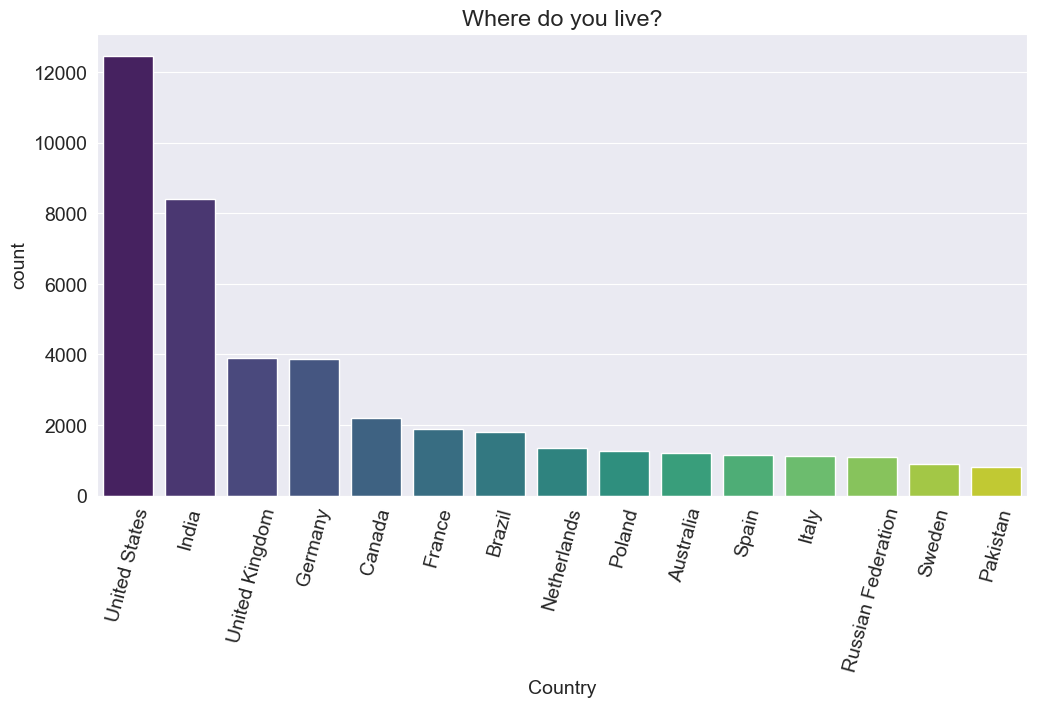

In [80]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
plt.title(schema.Country)
sns.barplot(x=top_countries.index, 
            y=top_countries,
            hue= top_countries.index,
            palette='viridis',
           legend=False)

(array([  210.,  2440.,  9196., 12016.,  8781.,  5607.,  3041.,  1763.,
         1039.,   623.,   334.,   144.,    75.]),
 array([10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70.,
        75.]),
 <BarContainer object of 13 artists>)

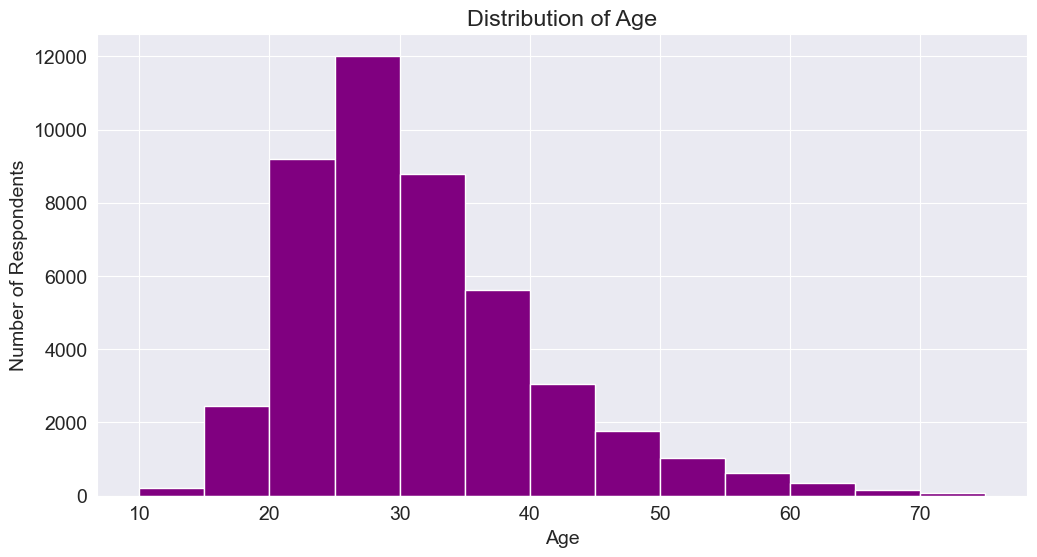

In [91]:
plt.figure(figsize=(12,6))
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of Respondents')
plt.hist(survey_df.Age, bins=np.arange(10,80,5), color='purple')

In [94]:
gender_counts=survey_df.Gender.value_counts()
gender_counts

Gender
Man                                                  45895
Woman                                                 3835
Non-binary, genderqueer, or gender non-conforming      385
Name: count, dtype: int64

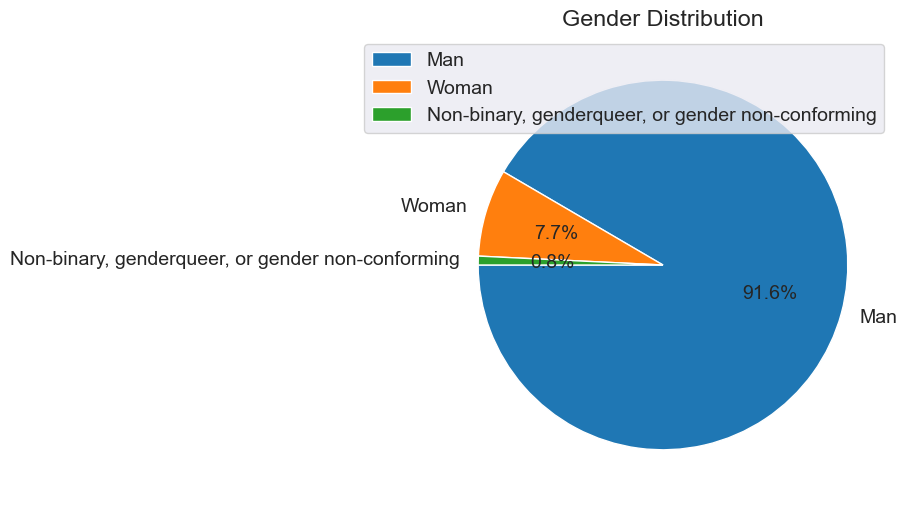

In [104]:
plt.figure(figsize=(12,6))
plt.title("Gender Distribution")
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=180)
plt.legend()

In [106]:
survey_df.EdLevel.unique()

array(['Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)', nan,
       'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
       'Professional degree (JD, MD, etc.)',
       'Some college/university study without earning a degree',
       'Associate degree (A.A., A.S., etc.)',
       'Other doctoral degree (Ph.D., Ed.D., etc.)',
       'Primary/elementary school',
       'I never completed any formal education'], dtype=object)

C:\Users\admin\AppData\Local\Temp\ipykernel_18484\2140815090.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=survey_df.EdLevel, palette='magma')


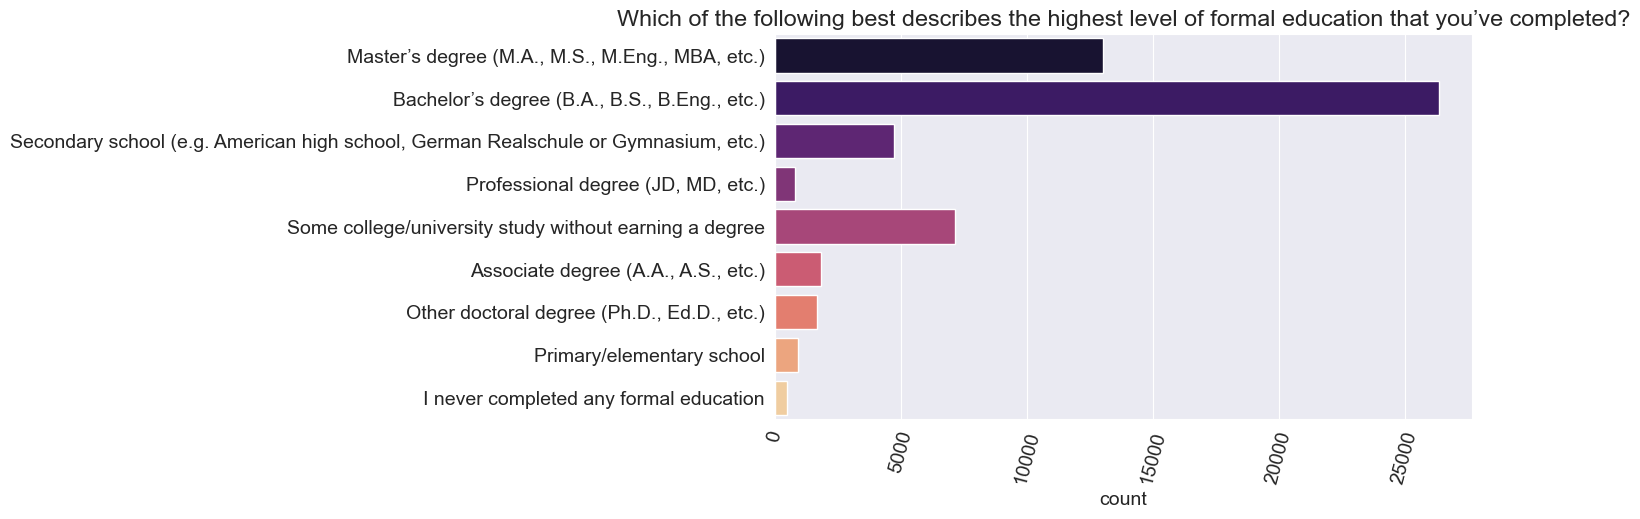

In [121]:
sns.countplot(y=survey_df.EdLevel, palette='magma')
plt.xticks(rotation=75);
plt.title(schema['EdLevel'])
plt.ylabel(None);
#plt.xlabel(None)

C:\Users\admin\AppData\Local\Temp\ipykernel_18484\3553611470.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=undergrad_pct, y=undergrad_pct.index, palette='crest')


Text(0.5, 0, 'Percentage')

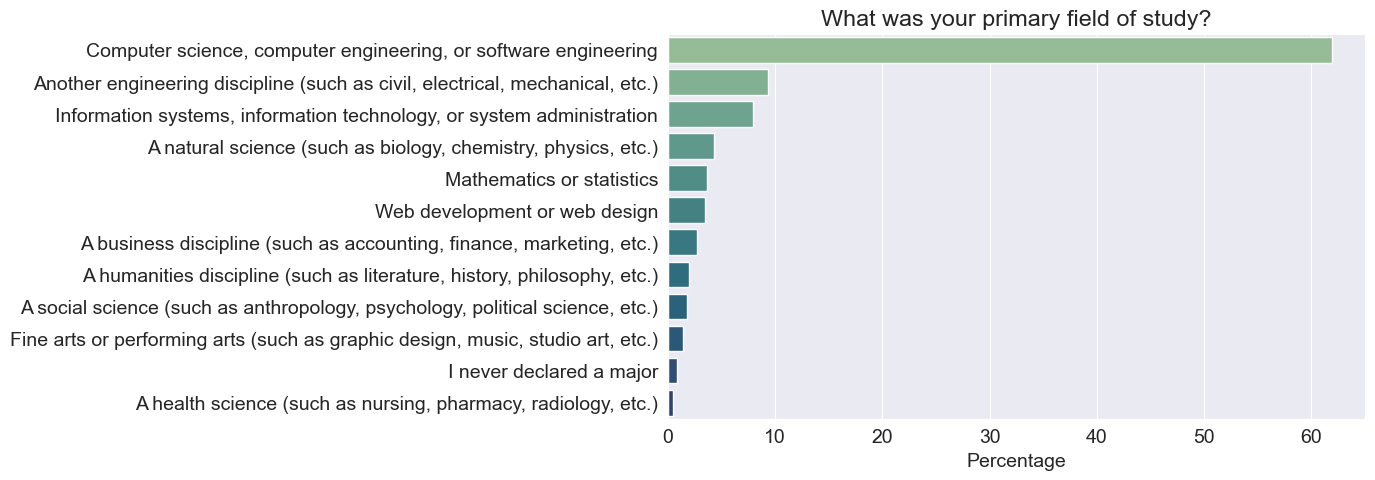

In [131]:
undergrad_pct = survey_df.UndergradMajor.value_counts() * 100 / survey_df.UndergradMajor.count()
sns.barplot(x=undergrad_pct, y=undergrad_pct.index, palette='crest')
plt.title(schema.UndergradMajor)
plt.ylabel(None)
plt.xlabel('Percentage')

In [133]:
schema.Employment

'Which of the following best describes your current employment status?'

In [134]:
survey_df.Employment.unique()

array(['Independent contractor, freelancer, or self-employed',
       'Employed full-time', nan, 'Student',
       'Not employed, but looking for work', 'Employed part-time',
       'Retired', 'Not employed, and not looking for work'], dtype=object)

Text(0, 0.5, '')

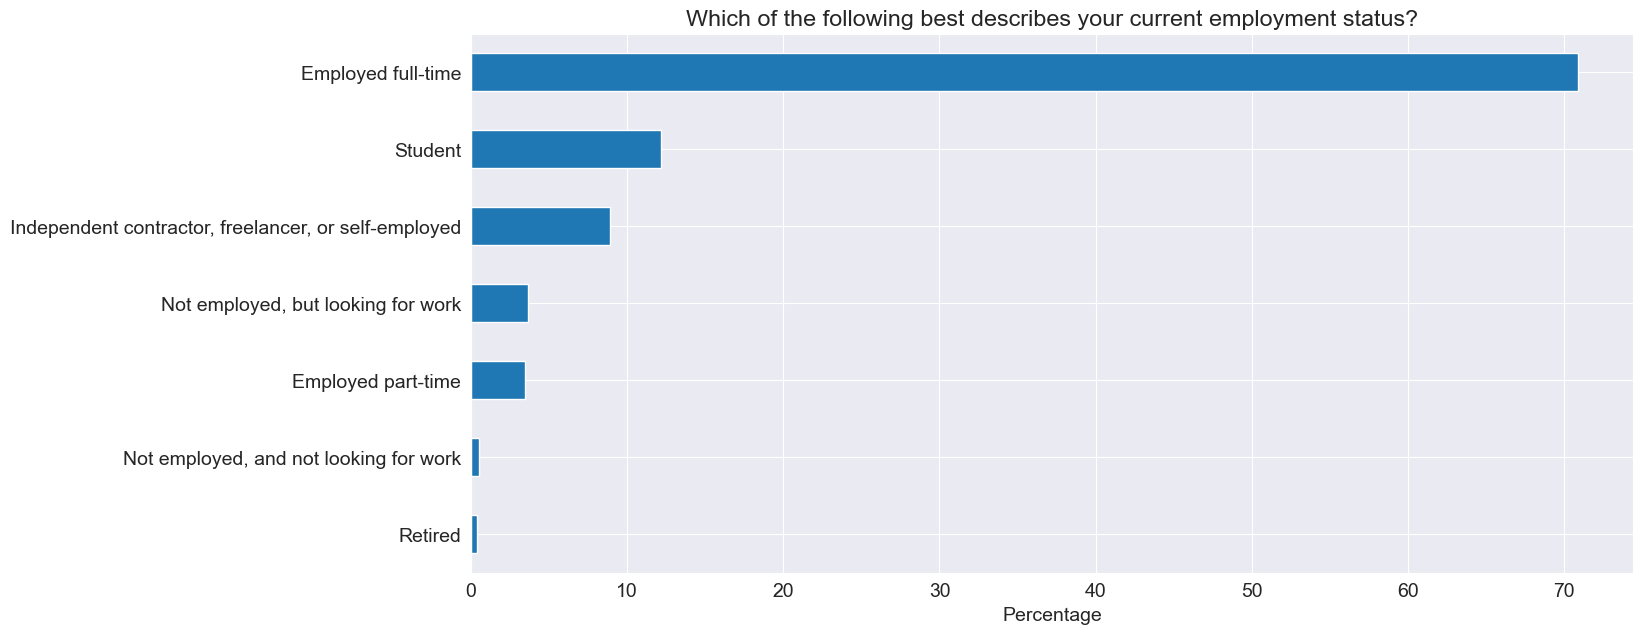

In [141]:
(survey_df.Employment.value_counts(normalize=True, ascending=True)*100).plot(kind="barh", figsize=(12,6))
plt.title(schema.Employment)
plt.xlabel('Percentage');
plt.ylabel(None)

In [142]:
schema.DevType

'Which of the following describe you? Please select all that apply.'

In [144]:
survey_df.DevType.value_counts()

DevType
Developer, full-stack                                                                                                                                                       4424
Developer, back-end                                                                                                                                                         3086
Developer, back-end;Developer, front-end;Developer, full-stack                                                                                                              2227
Developer, back-end;Developer, full-stack                                                                                                                                   1476
Developer, front-end                                                                                                                                                        1401
                                                                                                           

In [23]:
def split_multicolumn(col_series):
    result_df = col_series.to_frame()
    options = []

    for idx, value in col_series[col_series.notna()].items():
        for option in value.split(';'):
            option = option.strip()

            if option not in result_df.columns:
                options.append(option)
                result_df[option] = False

            result_df.at[idx, option] = True

    return result_df[options]


In [24]:
dev_type_df = split_multicolumn(survey_df.DevType)
dev_type_df

,"Developer, desktop or enterprise applications","Developer, full-stack","Developer, mobile",Designer,"Developer, front-end","Developer, back-end","Developer, QA or test",DevOps specialist,"Developer, game or graphics",Database administrator,...,System administrator,Engineering manager,Product manager,Data or business analyst,Academic researcher,Data scientist or machine learning specialist,Scientist,Senior executive/VP,"Engineer, site reliability",Marketing or sales professional
0,True,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
64457,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64459,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [163]:
dev_type_totals = dev_type_df.sum().sort_values(ascending=False)
dev_type_totals

Developer, back-end                              27228
Developer, full-stack                            27125
Developer, front-end                             18296
Developer, desktop or enterprise applications    11784
Developer, mobile                                 9482
DevOps specialist                                 5969
Database administrator                            5722
Designer                                          5321
System administrator                              5242
Developer, embedded applications or devices       4750
Data or business analyst                          4024
Data scientist or machine learning specialist     3988
Developer, QA or test                             3947
Engineer, data                                    3738
Academic researcher                               3552
Educator                                          2928
Developer, game or graphics                       2789
Engineering manager                               2724
Product ma

In [166]:
data_keywords = [
    "Data scientist",
    "Data analyst",
    "Data engineer",
    "Machine learning",
    "Engineer, data"
]

data_science_pct = (
    survey_df["DevType"]
    .str.contains("|".join(data_keywords), case=False, na=False)
    .mean() * 100
)

print(f"Percentage of respondents in data-related roles: {data_science_pct:.2f}%")


Percentage of respondents in data-related roles: 10.14%


In [175]:
survey_df.LanguageWorkedWith

0                                   C#;HTML/CSS;JavaScript
1                                         JavaScript;Swift
2                                 Objective-C;Python;Swift
3                                                      NaN
4                                        HTML/CSS;Ruby;SQL
                               ...                        
64456                                                  NaN
64457    Assembly;Bash/Shell/PowerShell;C;C#;C++;Dart;G...
64458                                                  NaN
64459                                             HTML/CSS
64460                      C#;HTML/CSS;Java;JavaScript;SQL
Name: LanguageWorkedWith, Length: 64461, dtype: object

In [55]:
language_worked_df = split_multicolumn(survey_df.LanguageWorkedWith)
language_worked_df

,C#,HTML/CSS,JavaScript,Swift,Objective-C,Python,Ruby,SQL,Java,PHP,...,VBA,Perl,Scala,C++,Go,Haskell,Rust,Dart,Julia,Assembly
0,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64457,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
64458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64459,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [181]:
language_worked_percentages= language_worked_df.mean().sort_values(ascending= False)*100
language_worked_percentages

JavaScript               60.225563
HTML/CSS                 56.128512
SQL                      48.731791
Python                   39.228371
Java                     35.795287
Bash/Shell/PowerShell    29.444160
C#                       27.987465
PHP                      23.280743
TypeScript               22.615225
C++                      21.264020
C                        19.371403
Go                        7.815578
Kotlin                    6.931323
Ruby                      6.276663
Assembly                  5.511860
VBA                       5.428088
Swift                     5.269853
R                         5.100759
Rust                      4.543833
Objective-C               3.630102
Dart                      3.537022
Scala                     3.183320
Perl                      2.786181
Haskell                   1.895720
Julia                     0.805138
dtype: float64

C:\Users\admin\AppData\Local\Temp\ipykernel_18484\3016348729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=language_worked_percentages, y=language_worked_percentages.index, palette='viridis')


Text(0.5, 0, 'Count')

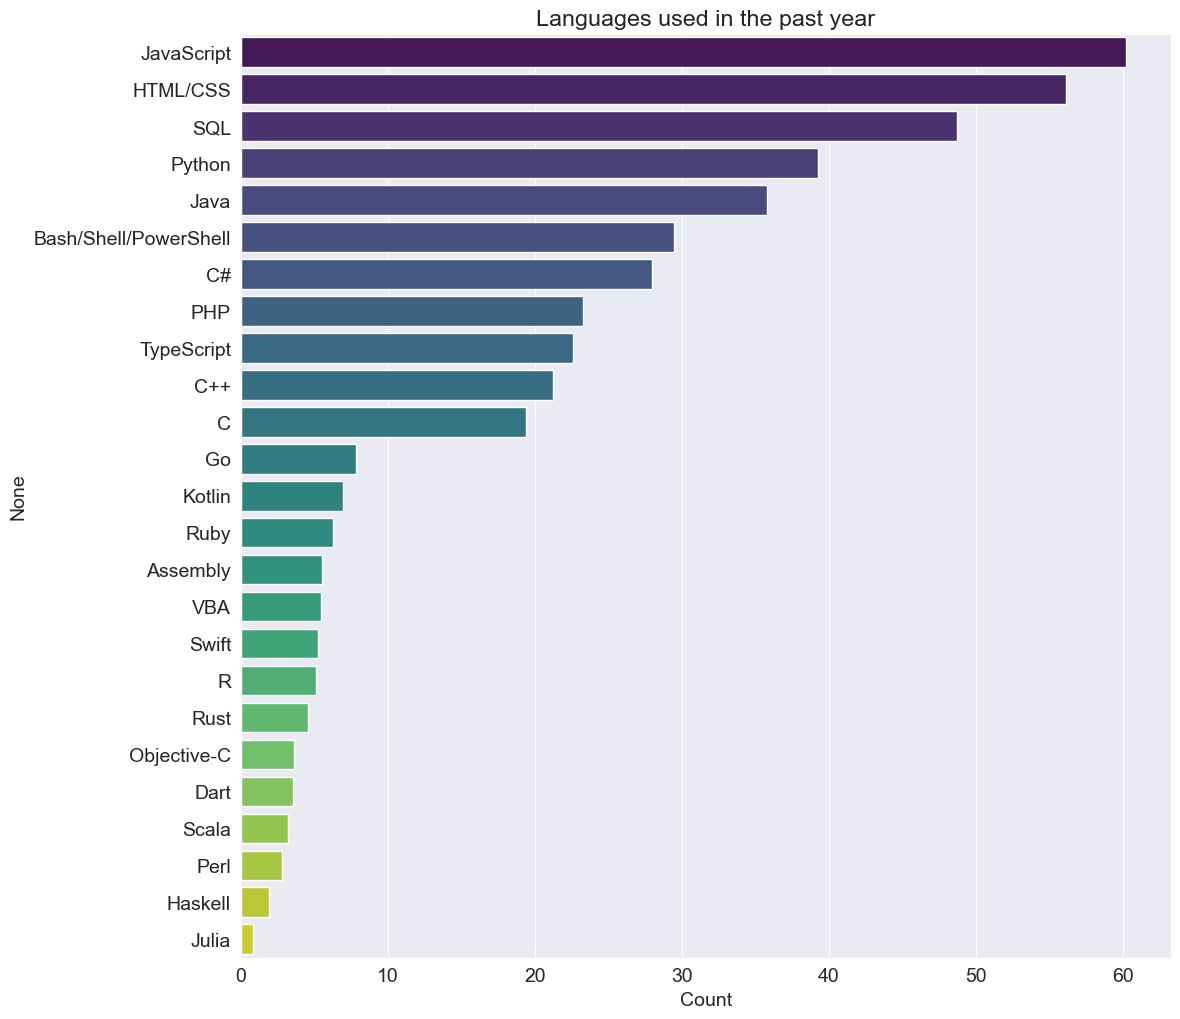

In [188]:
plt.figure(figsize=(12,12))
sns.barplot(x=language_worked_percentages, y=language_worked_percentages.index, palette='viridis')
plt.title("Languages used in the past year");
plt.xlabel('Count')

In [50]:
languages_intrested_df = split_multicolumn(survey_df.LanguageDesireNextYear)
languages_intrested_percentages= languages_intrested_df.mean().sort_values(ascending = False)
languages_intrested_percentages

Python                   0.413925
JavaScript               0.406261
HTML/CSS                 0.322226
SQL                      0.309800
TypeScript               0.266052
C#                       0.212128
Java                     0.205768
Go                       0.195545
Bash/Shell/PowerShell    0.181939
Rust                     0.163867
C++                      0.151347
Kotlin                   0.148539
PHP                      0.110237
C                        0.094491
Swift                    0.087541
Dart                     0.073564
R                        0.066257
Ruby                     0.064907
Scala                    0.053753
Haskell                  0.046478
Assembly                 0.038302
Julia                    0.025768
Objective-C              0.023658
Perl                     0.017840
VBA                      0.016366
dtype: float64

C:\Users\admin\AppData\Local\Temp\ipykernel_1560\3602355522.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=languages_intrested_percentages, y=languages_intrested_percentages.index, palette='magma')


Text(0.5, 0, 'count')

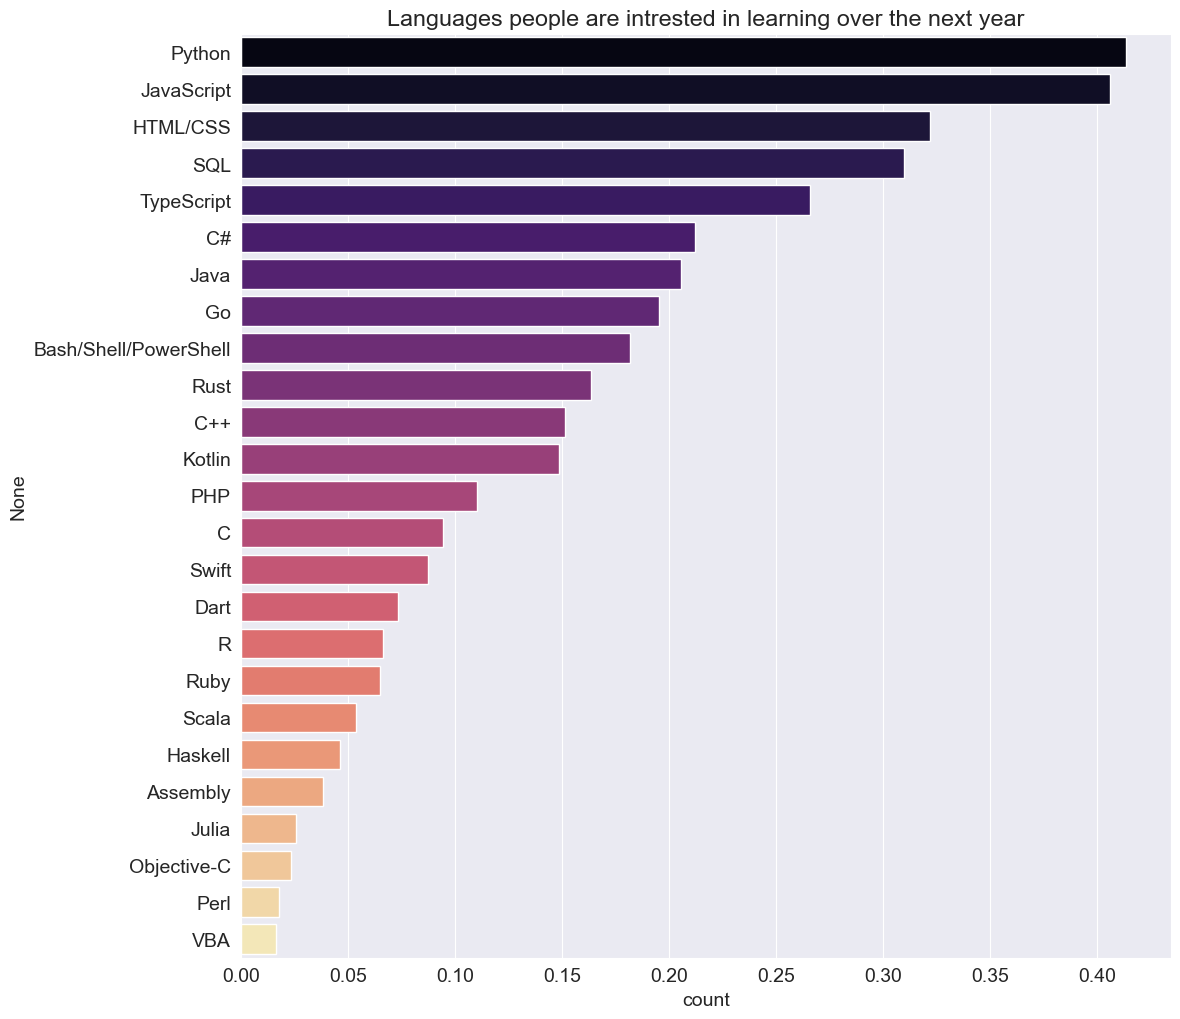

In [33]:
plt.figure(figsize=(12,12))
sns.barplot(x=languages_intrested_percentages, y=languages_intrested_percentages.index, palette='magma')
plt.title("Languages people are intrested in learning over the next year")
plt.xlabel('count')

In [47]:
languages_worked_df = split_multicolumn(survey_df.LanguageDesireNextYear)
languages_loved_percentages= languages_worked_df.mean().sort_values(ascending = False)
languages_loved_percentages

Python                   0.413925
JavaScript               0.406261
HTML/CSS                 0.322226
SQL                      0.309800
TypeScript               0.266052
C#                       0.212128
Java                     0.205768
Go                       0.195545
Bash/Shell/PowerShell    0.181939
Rust                     0.163867
C++                      0.151347
Kotlin                   0.148539
PHP                      0.110237
C                        0.094491
Swift                    0.087541
Dart                     0.073564
R                        0.066257
Ruby                     0.064907
Scala                    0.053753
Haskell                  0.046478
Assembly                 0.038302
Julia                    0.025768
Objective-C              0.023658
Perl                     0.017840
VBA                      0.016366
dtype: float64

In [62]:
language_loved_df =language_worked_df & languages_intrested_df
language_loved_df


,Assembly,Bash/Shell/PowerShell,C,C#,C++,Dart,Go,HTML/CSS,Haskell,Java,...,Perl,Python,R,Ruby,Rust,SQL,Scala,Swift,TypeScript,VBA
0,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64457,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
64458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64459,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [67]:
languages_loved_percentages = (languages_loved_df.sum() * 100/ language_worked_df.sum()).sort_values(ascending = False)
languages_loved_percentages

Rust                     360.635029
Julia                    320.038536
Go                       250.198491
Haskell                  245.171849
Kotlin                   214.301701
Dart                     207.982456
Scala                    168.859649
Swift                    166.117162
R                        129.896594
TypeScript               117.643024
Python                   105.516669
Ruby                     103.410776
C#                        75.794025
C++                       71.175312
Assembly                  69.490571
JavaScript                67.456597
Objective-C               65.170940
Perl                      64.031180
SQL                       63.572406
Bash/Shell/PowerShell     61.791359
Java                      57.484615
HTML/CSS                  57.408585
C                         48.778730
PHP                       47.351236
VBA                       30.151472
dtype: float64

C:\Users\admin\AppData\Local\Temp\ipykernel_1560\3486171487.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=languages_loved_percentages, y=languages_loved_percentages.index, palette='viridis')


Text(0.5, 0, 'count')

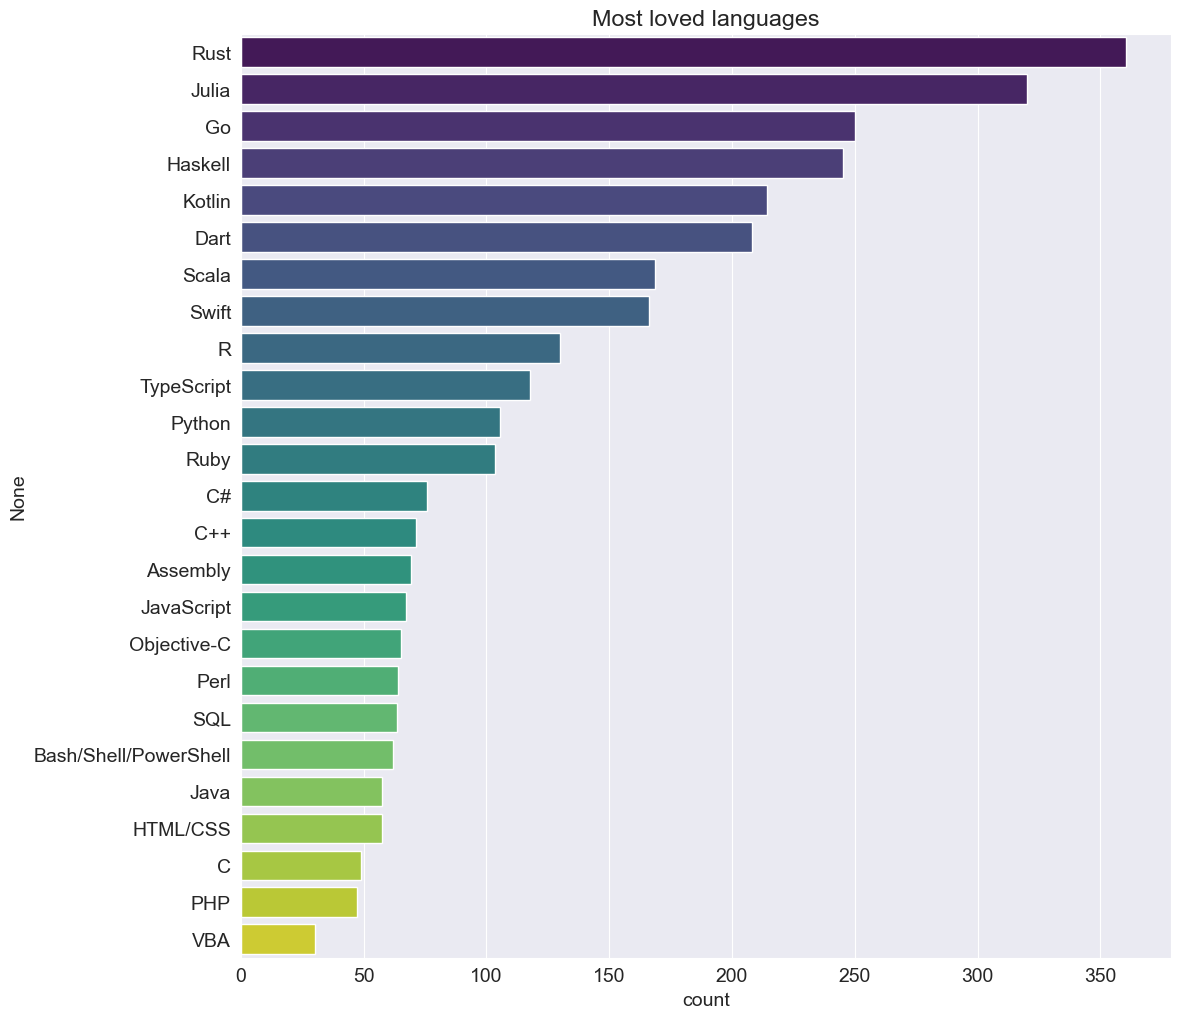

In [70]:
plt.figure(figsize = (12, 12))
sns.barplot(x=languages_loved_percentages, y=languages_loved_percentages.index, palette='viridis')
plt.title('Most loved languages')
plt.xlabel('count')

In [73]:
countries_df = survey_df.groupby('Country')[['WorkWeekHrs']].mean().sort_values('WorkWeekHrs', ascending= False)
countries_df

,WorkWeekHrs
Country,
Angola,72.333333
Kuwait,58.222222
Norway,55.451557
United Republic of Tanzania,55.384615
Finland,52.694828
...,...
North Korea,NaN
Saint Lucia,NaN
Sierra Leone,NaN


In [77]:
countries_df = countries_df.loc[survey_df.Country.value_counts()>250].head(15)
countries_df

,WorkWeekHrs
Country,
Norway,55.451557
Finland,52.694828
Iran,46.012903
Israel,44.744731
Turkey,43.772026
Austria,43.176923
Viet Nam,42.371901
China,42.134752
Hungary,41.926966


In [80]:
high_response_countries_df= countries_df.loc[survey_df.Country.value_counts()>250].head(15)
high_response_countries_df

,WorkWeekHrs
Country,
Norway,55.451557
Finland,52.694828
Iran,46.012903
Israel,44.744731
Turkey,43.772026
Austria,43.176923
Viet Nam,42.371901
China,42.134752
Hungary,41.926966


In [81]:
schema.YearsCodePro

'NOT including education, how many years have you coded professionally (as a part of your work)?'

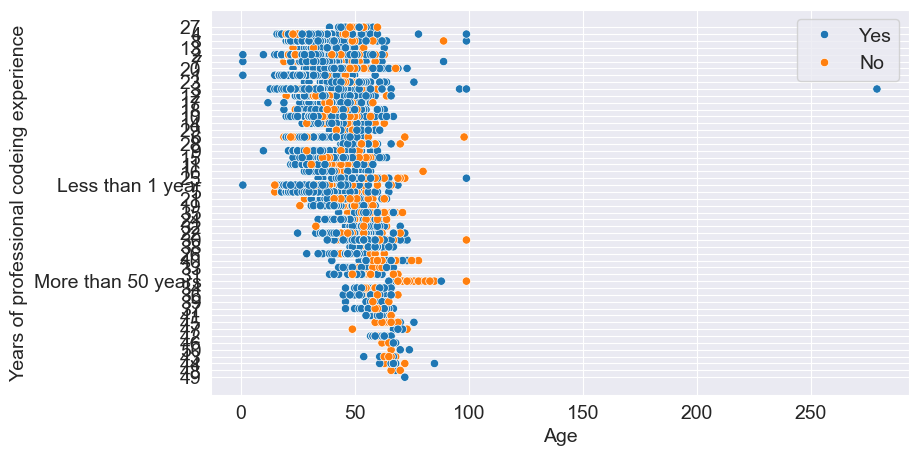

In [101]:
sns.scatterplot(
    x='Age',
    y='YearsCodePro',
    hue='Hobbyist',
    data=survey_df
)

plt.xlabel('Age')
plt.ylabel('Years of professional codeing experience')
plt.ylabel()
plt.legend(loc ='upper right')